In [39]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

$$ \frac{d^2y}{dx^2} = 4y^2 $$

In [40]:
# Notation u = y
# v = y' 

u0 = 0
v0 = 1
x_start = 0
x_end = 1
h = 1e-5
x = np.arange(x_start,x_end + h,step = h)
order = 2
f = lambda x,U:4*U[0]**2

def RK4(order,f,x,u0,v0,h):
    U = np.zeros(shape=(len(x),order),dtype= float)
    U[0] = u0,v0
    def functionvector(x,U,f):
        return np.array([U[1],f(x,U)])

    for i in tqdm(range(1,len(x))):
        k1 = h*functionvector(x[i-1],U[i-1],f)
        k2 = h*functionvector(x[i-1] + (h/2.0),U[i-1] + (k1/2.0),f)
        k3 = h*functionvector(x[i-1] + (h/2.0),U[i-1] + (k2/2.0),f)
        k4 = h*functionvector(x[i-1] + h,U[i-1] + k3,f)
        U[i] = U[i-1] + (1/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return U


result = RK4(order,f,x,u0,v0,h)
result[-1]

100%|██████████| 100000/100000 [00:00<00:00, 110027.81it/s]


array([1.40931392, 2.90935548])

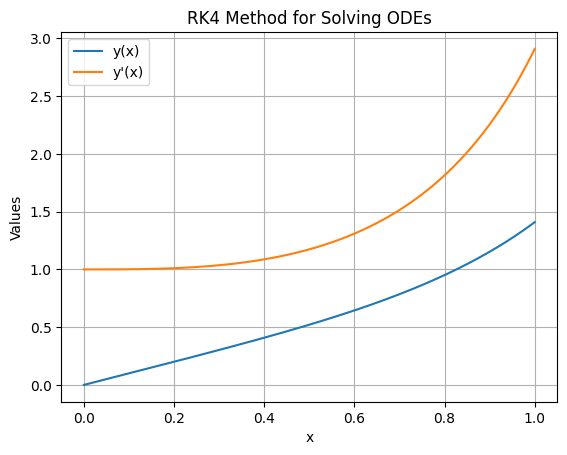

In [41]:
# Plotting the results
def analytical_solution(x):
    return np.sinh(2*x)/2
plt.plot(x, result[:, 0], label='y(x)')
plt.plot(x, result[:, 1], label="y'(x)")
plt.xlabel('x')
plt.ylabel('Values')
plt.title('RK4 Method for Solving ODEs')
plt.legend()
plt.grid()
plt.show()

In [42]:
#only for dd this is
def ShootingRK4(order,f,x,h,guess,u_xstart,u_xend,tolerance = 1e-6,max_iterations = 1000):
    def residue(y):
        return np.abs(y-u_xend)
    
    guess1 = guess[0]

    U1 = RK4(order,f,x,u_xstart + h*guess1,guess1,h)
    if residue(U1[-1,0]) < tolerance:
        return U1
    guess2 = guess[1]
    U2 = RK4(order,f,x,u_xstart + h*guess2,guess2,h)
    if residue(U2[-1,0]) < tolerance:
        return U2
    for i in tqdm(range(max_iterations)):
        if np.abs(residue(U2[-1,0]) - residue(U1[-1,0])) < 1e-12:
            raise ValueError("The method failed to converge due to identical residues. Please choose different initial guesses.")
        guess_new = guess2 - (U2[-1,0] - u_xend)*(guess2 - guess1)/(U2[-1,0] - U1[-1,0])
        U_new = RK4(order,f,x,u_xstart + h*guess_new,guess_new,h)
        if residue(U_new[-1,0]) < tolerance:
            return U_new
        guess1, U1 = guess2, U2
        guess2, U2 = guess_new, U_new
        
    return U2



In [43]:
f = lambda x,U : - U[1]**2/(U[0] + 1e-4)
h = 1e-5
order = 2
u_xstart = 0
u_xend = 1
x_start = 0
x_end = 1
x = np.arange(x_start,x_end + h,step = h)

Result = ShootingRK4(order=order,f=f,x=x,h=h,guess=[0.5,1.5],u_xstart=u_xstart,u_xend=u_xend,tolerance=1e-6,max_iterations=10)
print(Result[1,1])

 30%|███       | 3/10 [00:03<00:08,  1.25s/it]

126.36004689744739


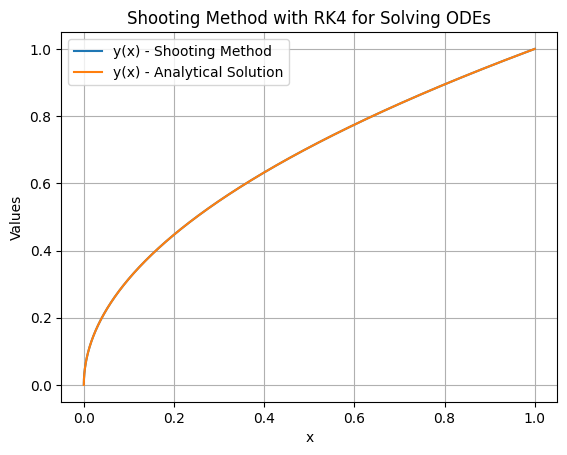

In [44]:
# Plotting the results  
def analytical_solution(x):
    return 1e-4 * (np.sqrt(100020000*x + 1) - 1)


plt.plot(x, Result[:, 0], label='y(x) - Shooting Method')
plt.plot(x, analytical_solution(x), label='y(x) - Analytical Solution')
plt.xlabel('x')
plt.ylabel('Values')
plt.title('Shooting Method with RK4 for Solving ODEs')
plt.legend()
plt.grid()
plt.show()


In [45]:
def RK4_Reverse(order, f, x, u_end, v_end, h):
    """
    Classical RK4 stepping along given x-array starting from the end value (x[0] is x_end).
    x is expected to be ordered in the direction of integration (here decreasing), and h
    should match the step between consecutive x entries (can be negative).

    Detects overflow/invalid values and prints x, y and y' at the first such point.
    """
    U = np.zeros(shape=(len(x), order), dtype=float)
    U[0] = u_end, v_end

    if not np.all(np.isfinite(U[0])):
        print(f"Overflow detected at x={x[0]}: y={U[0,0]}, y'={U[0,1]}")
        return U

    def functionvector(xi, Ui, f):
        return np.array([Ui[1], f(xi, Ui)])

    for i in tqdm(range(1, len(x))):
        k1 = h * functionvector(x[i - 1], U[i - 1], f)
        k2 = h * functionvector(x[i - 1] + (h / 2.0), U[i - 1] + (k1 / 2.0), f)
        k3 = h * functionvector(x[i - 1] + (h / 2.0), U[i - 1] + (k2 / 2.0), f)
        k4 = h * functionvector(x[i - 1] + h, U[i - 1] + k3, f)
        U[i] = U[i - 1] + (1 / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

        if not np.all(np.isfinite(U[i])):
            print(f"Overflow detected at x={x[i]}: y={U[i,0]}, y'={U[i,1]}")
            return U

    return U

In [46]:
def ShootingRK4Backward(order, f, x, h, guess, u_xstart, u_xend, tolerance=1e-6, max_iterations=1000):
    def residue(y):
        return np.abs(y - u_xstart)

    guess1 = guess[0]
    U1 = RK4_Reverse(order, f, x, u_xend - 1e-3, guess1, h)
    if np.isnan(U1).any():
        print("NaN encountered for initial guess1; aborting.")
        return U1
    if residue(U1[-1, 0]) < tolerance:
        return U1

    guess2 = guess[1]
    U2 = RK4_Reverse(order, f, x, u_xend - 1e-3, guess2, h)
    if np.isnan(U2).any():
        print("NaN encountered for initial guess2; aborting.")
        return U2
    if residue(U2[-1, 0]) < tolerance:
        return U2

    for _ in tqdm(range(max_iterations)):
        denom = U2[-1, 0] - U1[-1, 0]
        if np.abs(denom) < 1e-12:
            raise ValueError("The method failed to converge due to identical residues. Please choose different initial guesses.")
        guess_new = guess2 - (U2[-1, 0] - u_xstart) * (guess2 - guess1) / denom
        U_new = RK4_Reverse(order, f, x, u_xend - 1e-3, guess_new, h)
        if np.isnan(U_new).any():
            print("NaN encountered during iteration; aborting.")
            return U_new
        if residue(U_new[-1, 0]) < tolerance:
            return U_new
        guess1, U1 = guess2, U2
        guess2, U2 = guess_new, U_new

    return U2


  0%|          | 0/10 [00:00<?, ?it/s]/tmp/ipykernel_78017/1853320844.py:6: RuntimeWarning: overflow encountered in scalar power
  f = lambda x,U : - U[1]**2/(U[0] + 1e-4)
/tmp/ipykernel_78017/1853320844.py:6: RuntimeWarning: invalid value encountered in scalar divide
  f = lambda x,U : - U[1]**2/(U[0] + 1e-4)
  0%|          | 0/10 [00:00<?, ?it/s]


Overflow detected at x=0.73852000000119: y=-inf, y'=nan
NaN encountered during iteration; aborting.


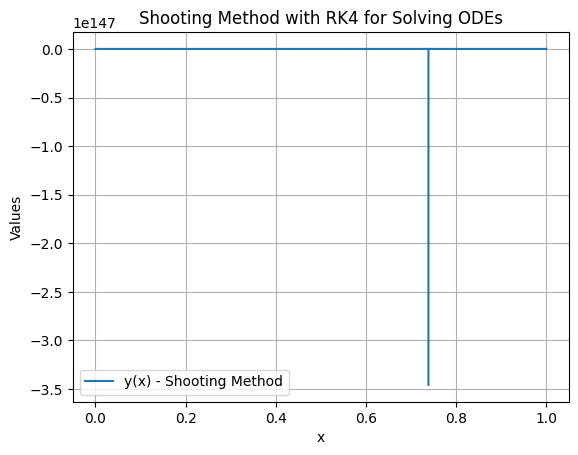

In [47]:
# Plotting the results  
def analytical_solution(x):
    return 1e-4 * (np.sqrt(100020000*x + 1) - 1)

order = 2
f = lambda x,U : - U[1]**2/(U[0] + 1e-4)
h = -1e-5
u_xstart = 0
u_xend = 1
x = np.arange(x_end,x_start,step = h)  # Reverse x for backward integration

Result_backword = ShootingRK4Backward(order=order,f=f,x=x,h=-h,guess=[0.5,1.5],u_xstart=u_xstart,u_xend=u_xend,tolerance=1e-6,max_iterations=10)

plt.plot(x, Result_backword[:, 0], label='y(x) - Shooting Method')
# plt.plot(x, analytical_solution(x), label='y(x) - Analytical Solution')
plt.xlabel('x')
plt.ylabel('Values')
plt.title('Shooting Method with RK4 for Solving ODEs')
plt.legend()
plt.grid()
plt.show()


$$ \frac{d^2y}{dx^2} = \frac{-\frac{dy}{dx}^2}{y + 0.0001} $$
$$y(0) = 0, y(1) = 1 $$

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def RK4_Reverse(order, f, x, u_end, v_end, h, max_derivative=1e4):
    """
    RK4 with overflow protection and derivative limiting.
    """
    U = np.zeros(shape=(len(x), order), dtype=float)
    U[0] = u_end, v_end

    def functionvector(xi, Ui, f):
        # Add safeguard against division by very small numbers
        if Ui[0] + 1e-4 < 1e-8:
            return np.array([Ui[1], 0])
        return np.array([Ui[1], f(xi, Ui)])

    for i in tqdm(range(1, len(x))):
        k1 = h * functionvector(x[i-1], U[i-1], f)
        k2 = h * functionvector(x[i-1] + h/2, U[i-1] + k1/2, f)
        k3 = h * functionvector(x[i-1] + h/2, U[i-1] + k2/2, f)
        k4 = h * functionvector(x[i-1] + h, U[i-1] + k3, f)
        U[i] = U[i-1] + (1/6) * (k1 + 2*k2 + 2*k3 + k4)

        # Check for overflow
        if not np.all(np.isfinite(U[i])) or abs(U[i,1]) > max_derivative:
            print(f"Overflow at x={x[i]:.6f}: y={U[i,0]}, y'={U[i,1]}")
            return None
    
    return U

# Main shooting method
order = 2
f = lambda x, U: -U[1]**2 / (U[0] + 1e-4)

x_start = 0
x_end = 1
h = -1e-6  # Smaller step size

x = np.arange(x_end, x_start, h)

# Better initial guesses
analytical_slope_at_1 = 5000 / np.sqrt(100020001)  # ≈ 0.05
guess = [analytical_slope_at_1 * 0.95, analytical_slope_at_1 * 1.05]

Result_backward = ShootingRK4Backward(
    order=order, f=f, x=x, h=h,
    guess=guess, u_xstart=u_xstart, u_xend=u_xend,
    tolerance=1e-6, max_iterations=20
)

if Result_backward is not None and not np.isnan(Result_backward).any():
    plt.plot(x, Result_backward[:, 0], label='Backward Shooting', linewidth=2)
    plt.plot(x, analytical_solution(x), '--', label='Analytical', alpha=0.7)
    plt.xlabel('x')
    plt.ylabel('y(x)')
    plt.legend()
    plt.grid()
    plt.show()

  0%|          | 0/999999 [00:00<?, ?it/s]

 95%|█████████▌| 951619/999999 [00:11<00:00, 85427.37it/s]

Overflow at x=0.048380: y=-0.011499894145527467, y'=11578.485939013613


TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''